# **Amazon Web Service (AWS) SaaS Sales Performance Analysis: Identifying Profit Loss Drivers in Japan (2020 - 2023)**

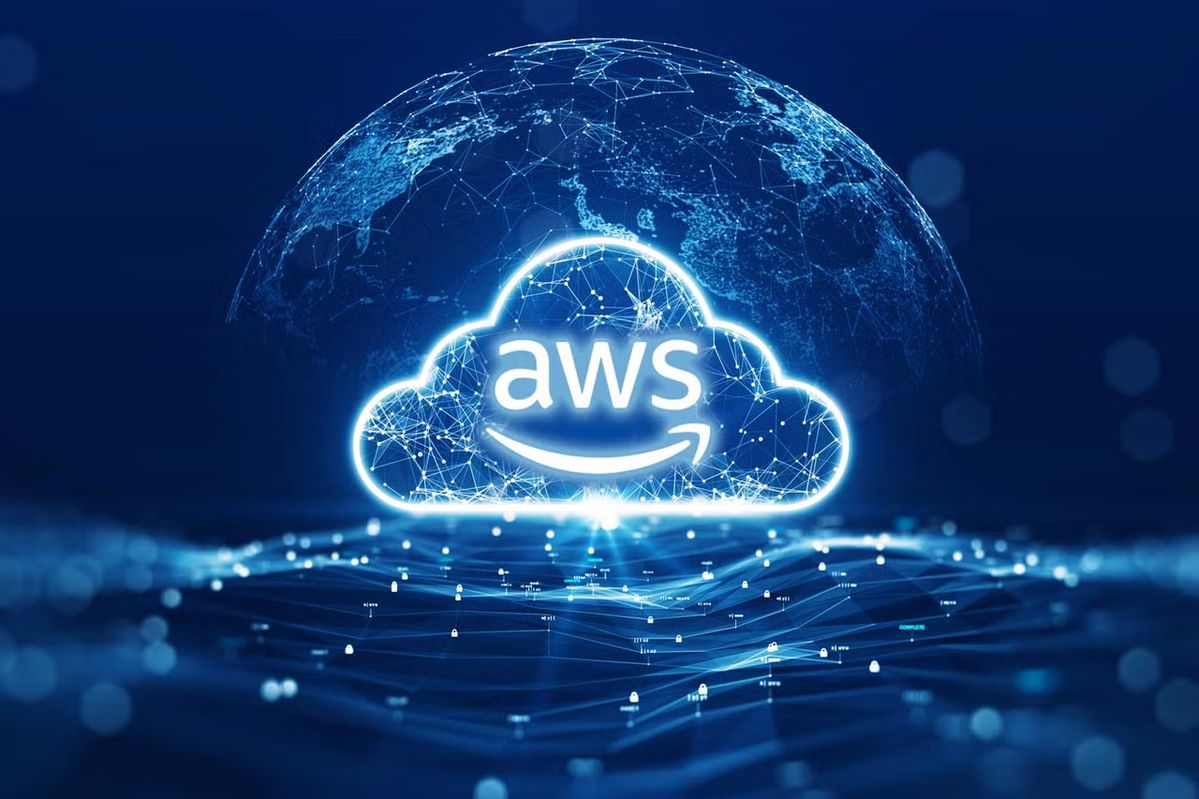

## **Project Context**

This dataset contains sales data for SaaS (Software as a Service) products sold by the Amazon Web Service to various companies worldwide. The data covers transaction information such as country, product, segment, discount, sales, and profit from 2020 to 2023. As a Data Analyst, our task is to identify business areas experiencing losses and uncover their root causes, so the company can make informed decisions to improve business performance.

## **Stakeholders**

- **Sales Manager** – Responsible for discount policies and sales targets in each region.
- **Regional Director APJ** – Decision-maker for business strategy in the Asia Pacific & Japan region.
- **Finance Team** – Monitors overall company profitability.

## **Problem Statement**

AWS SaaS recorded consistent profit growth overall, yet the APJ region, particularly Japan, has generated a total loss of -$25,729 despite being the top revenue generator in the region.

This analysis aims to answer the following questions:

1. Where do the largest losses occur, and which products contribute the most?
2. What causes those products to be unprofitable in Japan, and what recommendations can be made to address the losses?

## **IMPORTING DATASET**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_rows',100)

import folium
import requests
import geocoder
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from folium.plugins import MarkerCluster, HeatMap


import matplotlib.colors as mcolors
import matplotlib.cm as cm
import json

In [40]:
df = pd.read_csv('SaaS-Sales.csv')
df.head()                                       

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


## **Dataset Overview**

The dataset used in this analysis is the AWS SaaS Sales dataset, which records B2B transactions of the Amazon Web Service (AWS) SaaS company selling sales and marketing software 
to businesses worldwide. Each row represents a single product within a transaction. 
The dataset consists of 9,994 rows and 19 columns, as described below:

| Column | Description |
|--------|-------------|
| Row ID | Sequential identifier for each row in the dataset |
| Order ID | Unique code assigned to each order |
| Order Date | Date the order was placed |
| Date Key | Numeric format of the order date (YYYYMMDD) |
| Contact Name | Name of the individual who made the purchase |
| Country | Country where the transaction occurred |
| City | City where the transaction occurred |
| Region | Broad geographical region of the transaction |
| Subregion | More specific geographical area within the region |
| Customer | Name of the company that made the purchase |
| Customer ID | Unique identifier assigned to each customer |
| Industry | Industry sector the customer belongs to |
| Segment | Business segment of the customer (SMB, Strategic, Enterprise) |
| Product | Name of the product purchased |
| License | License key associated with the purchased product |
| Sales | Total revenue generated from the transaction |
| Quantity | Number of product units included in the transaction |
| Discount | Discount rate applied to the transaction (0 to 1) |
| Profit | Net profit earned from the transaction |

## **BASIC DATA UNDERSTANDING**

This step provides an initial overview of the dataset to better understand its structure and quality. This includes examining data types, summary statistics, missing values, and the number of unique values in each column. These insights help identify potential data issues and guide the subsequent data cleaning and analysis process.

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

In [42]:
df.describe()

,Row ID,Date Key,Customer ID,Sales,Quantity,Discount,Profit
count,9994.000000,9.994000e+03,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2.021803e+07,1049.771963,229.858001,3.789574,0.156203,28.656896
std,2885.163629,1.123898e+04,29.719388,623.245101,2.225110,0.206452,234.260108
min,1.000000,2.020010e+07,1001.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2.021052e+07,1024.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2.022063e+07,1049.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2.023052e+07,1076.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2.023123e+07,1101.000000,22638.480000,14.000000,0.800000,8399.976000


In [43]:
df.isnull().sum()

Row ID          0
Order ID        0
Order Date      0
Date Key        0
Contact Name    0
Country         0
City            0
Region          0
Subregion       0
Customer        0
Customer ID     0
Industry        0
Segment         0
Product         0
License         0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [44]:
df.nunique()

Row ID          9994
Order ID        5009
Order Date      1237
Date Key        1237
Contact Name     793
Country           48
City             262
Region             3
Subregion         12
Customer          99
Customer ID       99
Industry          10
Segment            3
Product           14
License         9994
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

## **DATA CLEANING AND MANIPULATING**

This stage focuses on preparing the dataset for analysis by addressing data quality issues, ensuring consistency, and transforming variables into appropriate formats. These steps are essential to improve data reliability and support accurate analytical results.

### **1. Fixing Datatypes**

This step ensures that each column has the correct data type, which is crucial for accurate processing, analysis, and visualization.

In [45]:
# Order time is still object --> Changing the type to datetime 
df['Order Date'] = pd.to_datetime(df['Order Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   object        
 2   Order Date    9994 non-null   datetime64[ns]
 3   Date Key      9994 non-null   int64         
 4   Contact Name  9994 non-null   object        
 5   Country       9994 non-null   object        
 6   City          9994 non-null   object        
 7   Region        9994 non-null   object        
 8   Subregion     9994 non-null   object        
 9   Customer      9994 non-null   object        
 10  Customer ID   9994 non-null   int64         
 11  Industry      9994 non-null   object        
 12  Segment       9994 non-null   object        
 13  Product       9994 non-null   object        
 14  License       9994 non-null   object        
 15  Sales         9994 non-null   float64 

### **2. Check and Handle Duplicates**

This step identifies and removes duplicate records to prevent data redundancy, which could otherwise lead to biased or inaccurate analysis results.

In [46]:
df.duplicated().sum()

# No need to handle duplicates since there are already none

np.int64(0)

### **3. Checking Missing Values**

This step examines the dataset for missing or null values and determines appropriate handling methods, such as imputation or removal, to maintain data integrity.

In [47]:
df.isna().sum()/df.shape[0]*100

Row ID          0.0
Order ID        0.0
Order Date      0.0
Date Key        0.0
Contact Name    0.0
Country         0.0
City            0.0
Region          0.0
Subregion       0.0
Customer        0.0
Customer ID     0.0
Industry        0.0
Segment         0.0
Product         0.0
License         0.0
Sales           0.0
Quantity        0.0
Discount        0.0
Profit          0.0
dtype: float64

### **4. Data Consistency for the Categorical Columns**

This step ensures that categorical variables are standardized and consistent, including correcting typos, unifying formats, and aligning naming conventions.

In [48]:
# To check for typographical errors

for col in ['Country', 'City', 'Product', 'Industry', 'Segment'] :
    print(col, df[col].str.lower().str.strip().nunique())

Country 48
City 262
Product 14
Industry 10
Segment 3


In [49]:
# To remove unnecessary whitespace

cols_str = ['Country', 'City', 'Region', 'Subregion', 'Customer', 'Industry', 'Segment', 'Product', 'License', 'Contact Name']

for col in cols_str: 
    df[col] = df[col].str.strip()

In [50]:
# To standardize text into title case

for col in ['Country', 'City', 'Product', 'Industry', 'Segment']:
    df[col] = df[col].str.title()

### **5. Logical Consistency for the Numerical Columns**

This step ensures that numerical variables fall within logical and acceptable ranges. It helps identify potential data entry errors, anomalies, or invalid values that may affect analysis.

In [51]:
# Sales: Identify any negative sales values

df[df['Sales'] < 0]

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit


In [52]:
# Quantity: Identify zero or negative quantities

df[df['Quantity'] <= 0]

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit


In [53]:
# Discount: Ensure discount values are within the valid range (0 to 1)

df[(df['Discount'] < 0) | (df['Discount'] > 1)]

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit


In [54]:
# Profit: Review the lowest profit values to detect potential anomalies or extreme losses

df.sort_values('Profit').head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
7772,7773,AMER-2022-108196,2022-11-26,20221126,Faith Campbell,Mexico,Tijuana,AMER,LATAM,Allstate,1003,Finance,Smb,Big Ol Database,PM66ENV0DN,4499.985,5,0.7,-6599.9780
683,684,EMEA-2023-168116,2023-11-05,20231105,Emily Fisher,Sweden,Gothenburg,EMEA,NOR,Costco Wholesale,1025,Retail,Strategic,Big Ol Database,BT5A3EPA0H,7999.980,4,0.5,-3839.9904
9774,9775,APJ-2020-169019,2020-07-26,20200726,Lily Bond,Japan,Osaka,APJ,JAPN,Bosch,1076,Tech,Smb,Contactmatcher,FT1VQ5PHAG,2177.584,8,0.8,-3701.8928
3011,3012,EMEA-2023-134845,2023-04-18,20230418,Joshua Vaughan,Russia,Moscow,EMEA,EU-EAST,FedEx,1036,Transportation,Enterprise,Big Ol Database,UN48B3LEBM,2549.985,5,0.7,-3399.9800
4991,4992,APJ-2023-122714,2023-12-08,20231208,Ruth Vaughan,Australia,Sydney,APJ,ANZ,Ford Motor,1009,Manufacturing,Strategic,Contactmatcher,WWN9Y458G2,1889.990,5,0.8,-2929.4845


### **6. Checking Outliers**

This step detects extreme values that significantly deviate from the rest of the data, which may indicate errors or important patterns that require further investigation.


In [55]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe() 

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


<Axes: ylabel='Sales'>

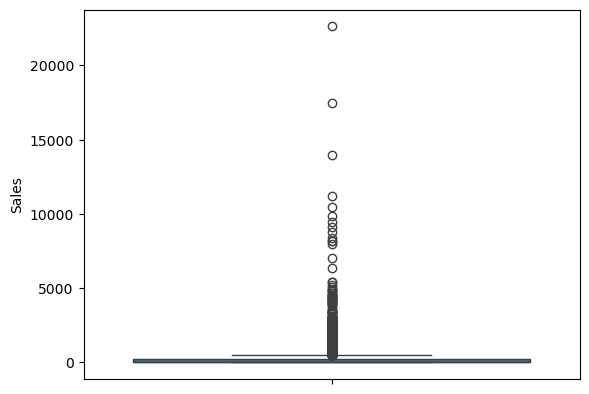

In [56]:
# Checking outliers with boxplot

sns.boxplot(y=df['Sales'])

<Axes: ylabel='Discount'>

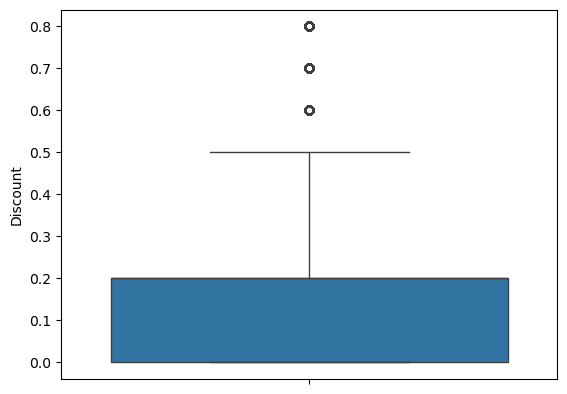

In [57]:
sns.boxplot(y=df['Discount'])

<Axes: ylabel='Profit'>

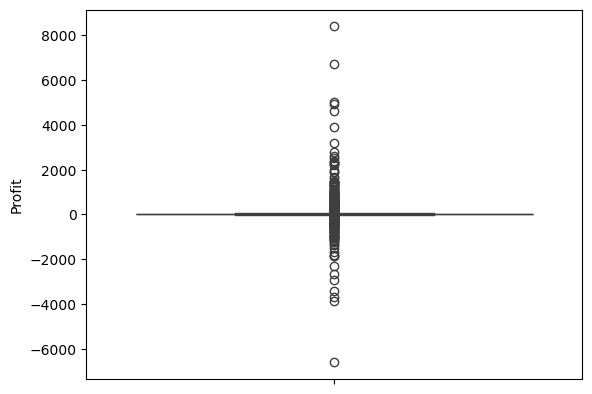

In [58]:
sns.boxplot(y=df['Profit'])

### **7. Drop Unused Columns**

The 'Date Key' column is removed as it contains the same information as 'Order Date'. The 'Row ID' column is dropped since it only represents an index and does not add analytical value. Additionally, the 'Contact Name' column is excluded as it is not relevant for the analysis.

In [59]:
df = df.drop(columns=['Date Key', 'Row ID', 'Contact Name'])

In [60]:
df

,Order ID,Order Date,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,EMEA-2022-152156,2022-11-09,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,Smb,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,EMEA-2022-152156,2022-11-09,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,Smb,Financehub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,AMER-2022-138688,2022-06-13,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,Financehub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,EMEA-2021-108966,2021-10-11,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,Smb,Contactmatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,EMEA-2021-108966,2021-10-11,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,Smb,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,EMEA-2020-110422,2020-01-22,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,Healthcare,Smb,Saas Connector Pack,ETHXMB5TMD,25.2480,3,0.20,4.1028
9990,AMER-2023-121258,2023-02-27,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,Smb,Saas Connector Pack,LYHOKTRY7L,91.9600,2,0.00,15.6332
9991,AMER-2023-121258,2023-02-27,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,Smb,Site Analytics,I5SVMI6M88,258.5760,2,0.20,19.3932
9992,AMER-2023-121258,2023-02-27,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,Smb,Support,JHLW4P6LQ2,29.6000,4,0.00,13.3200


## **EXPORTING CLEANED DATASET**

In [84]:
# Export cleaned dataset
df.to_csv('SaaS-Sales-Cleaned.csv', index=False)
print("Dataset exported successfully!")

Dataset exported successfully!


## **EXPLORATORY DATA ANALYSIS**

This stage explores the cleaned dataset to uncover initial patterns, distributions, and relationships between variables. The goal is to gain a deeper understanding of the data before conducting a more focused analysis, and to identify early signals that may guide the direction of the investigation.

### **PROFIT DISTRIBUTION**

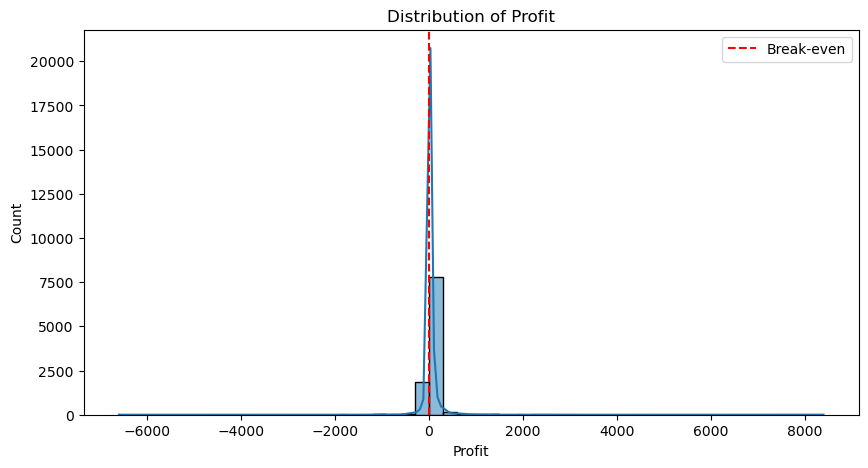

In [61]:
plt.figure(figsize=(10,5))
sns.histplot(df['Profit'], bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--', label='Break-even')
plt.title('Distribution of Profit')
plt.legend()
plt.show()

*Description:*

The profit distribution is highly concentrated around zero, indicating that most transactions generate a relatively small profit or loss. However, there are transactions on both extremes — some generating significant profits (up to +8,000) and some incurring heavy losses (down to -6,000). Although these extreme cases are few in number, they signal that certain transactions are significantly underperforming and warrant deeper investigation.

### **DISCOUNT DISTRIBUTION**

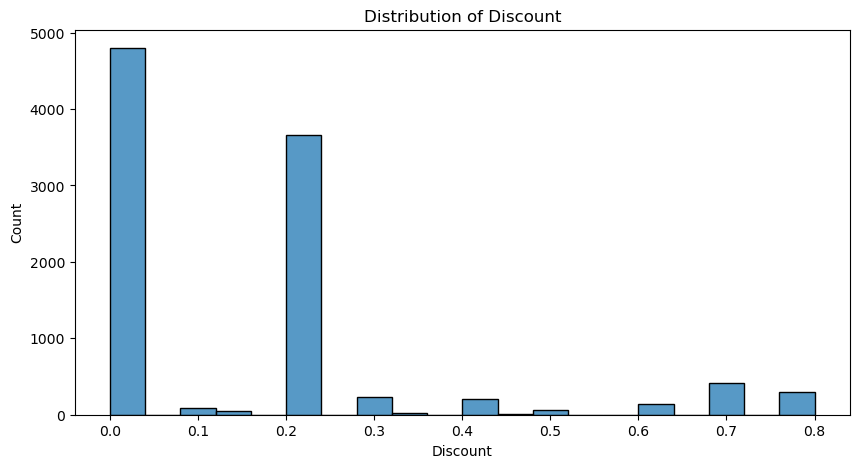

In [62]:
plt.figure(figsize=(10,5))
sns.histplot(df['Discount'], bins=20)
plt.title('Distribution of Discount')
plt.show()

*Description:*

The discount distribution shows two dominant groups: transactions with no discount (0%) and transactions with a 20% discount, which together account for the majority of all transactions. However, there are also 
transactions with significantly high discount levels, particularly at 70% and 80%, which — although small in number — are worth investigating further as they may be contributing to the losses identified earlier.

### **HEATMAP CORRELATION**

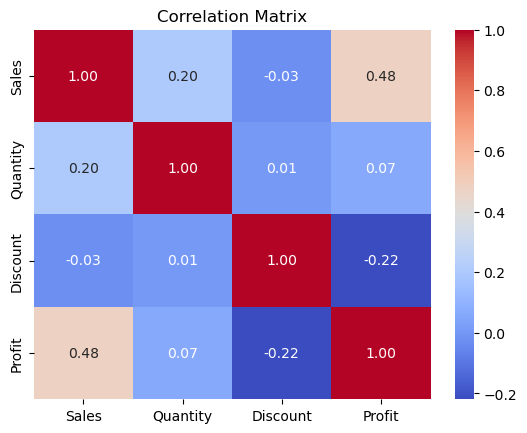

In [63]:
sns.heatmap(df[['Sales','Quantity','Discount','Profit']].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

*Description:*

The correlation matrix highlights two key relationships. First, Sales and Profit show a moderate positive correlation (+0.48), meaning higher sales generally lead to higher profit. Second, and more importantly, Discount shows a negative correlation with Profit (-0.22), confirming that higher discounts tend to reduce profitability. Notably, Discount has almost no correlation with Sales (-0.03), meaning that offering higher discounts does not necessarily drive more sales. This early finding strongly suggests that discount strategy is a critical factor affecting profitability and will be investigated further in the analysis.

## **DATA ANALYSIS**

This stage focuses on exploring the dataset to uncover patterns, trends, and key insights. The analysis aims to support data-driven decision-making by examining relationships between variables and identifying meaningful business implications.

### **YEARLY TREND**

This analysis examines yearly trends in Sales, Profit, and Quantity to understand overall business performance over time. It helps identify growth patterns, fluctuations, and potential inconsistencies between revenue and profitability.

In [64]:
yearly_detail = df.groupby(df['Order Date'].dt.year).agg({'Sales': 'sum', 'Profit': 'sum', 'Quantity': 'sum'}).reset_index()

yearly_detail.rename(columns={'Order Date': 'Year'}, inplace=True)

yearly_detail 

,Year,Sales,Profit,Quantity
0,2020,484247.4981,49543.9741,7581
1,2021,470532.5090,61618.6037,7979
2,2022,608473.8300,81726.9308,9810
3,2023,733947.0232,93507.5131,12503


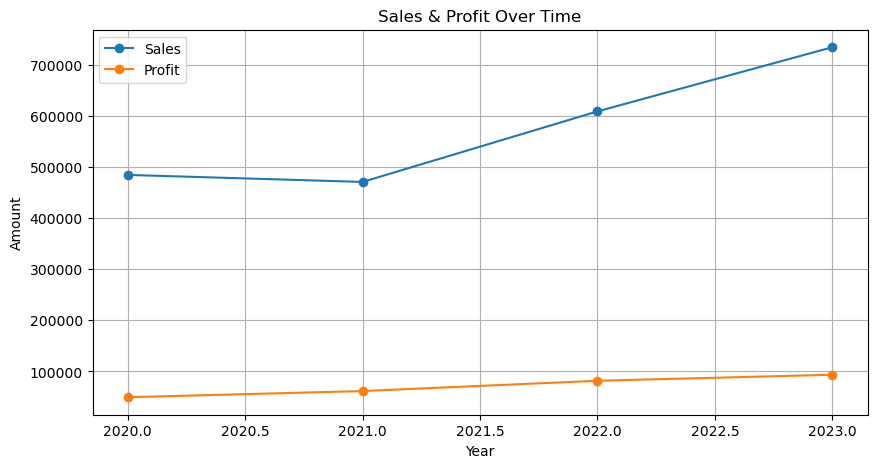

In [65]:
# Line plot for both Profit and Sales per year

plt.figure(figsize=(10,5))

plt.plot(yearly_detail['Year'], yearly_detail['Sales'], marker='o', label='Sales')
plt.plot(yearly_detail['Year'], yearly_detail['Profit'], marker='o', label='Profit')

plt.title('Sales & Profit Over Time')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid()

plt.show()

#### **Explanations for the Yearly Sales and Profit Performance (2020–2023)**

*Description:* 

The company shows a strong growth trend from 2020 to 2023. Sales increased from $484k to $733k, and Profit almost doubled from $49k to $93k. A good sign happened in 2021, where the profit still went up even though sales dropped a little.

*Note:*

While the total profit looks good, we cannot assume there are no problems. High overall profit can hide big losses in certain areas. For example, even if the company is winning globally, there specific countries that might still be losing money. We need to look closer at each region to fix these hidden losses.

### **GEOGRAPHICAL ANALYSIS**

This analysis explores business performance across different geographical levels, including region, subregion, and country. The objective is to identify areas that significantly contribute to overall performance, particularly those with low or negative profit.

#### **A. Region**

This step analyzes performance at the regional level to identify which regions contribute the most and least to overall profit. It serves as a starting point for deeper geographical analysis.

In [66]:
region_detail = df.groupby('Region')[['Sales','Profit']].sum().sort_values(by='Profit', ascending=False)
region_detail

,Sales,Profit
Region,,
EMEA,1.043887e+06,147456.0450
AMER,8.378496e+05,127426.9898
APJ,4.154642e+05,11513.9869


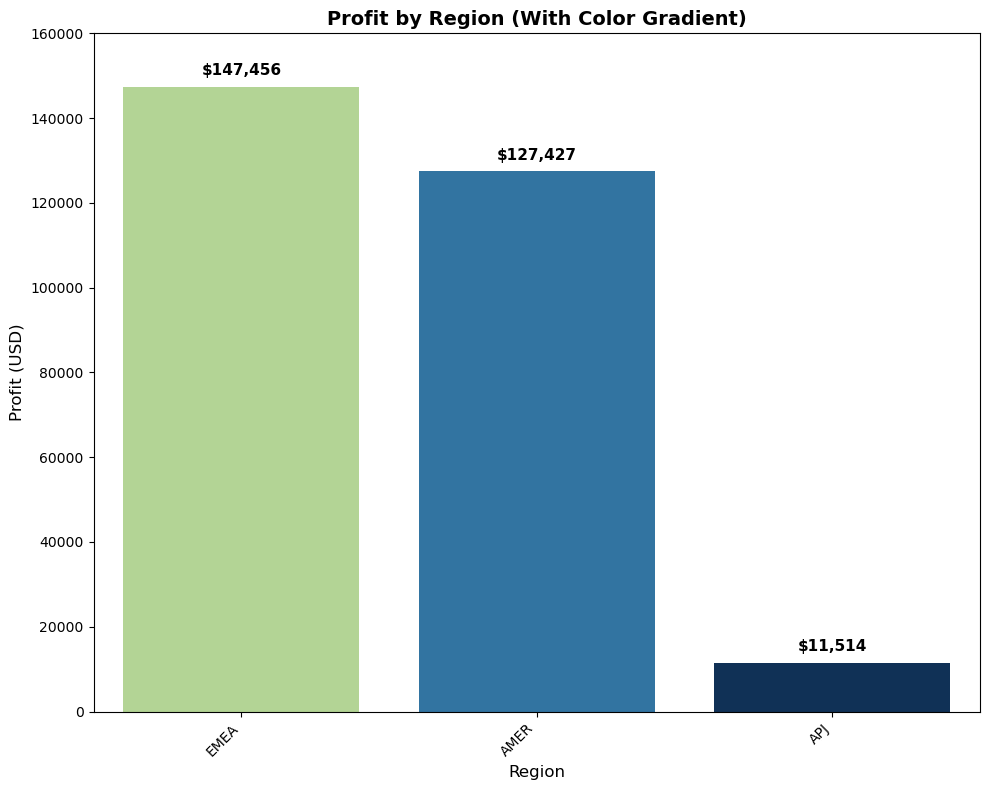

In [67]:
# Bar Chart Profit by Region

data = {'Region': ['APJ', 'AMER', 'EMEA'], 'Profit': [11514, 127427, 147456]}
df_region = pd.DataFrame(data)

region_order = ['EMEA', 'AMER', 'APJ']
region_profit = df_region.set_index('Region').reindex(region_order).reset_index()

min_profit = region_profit['Profit'].min()
max_profit = region_profit['Profit'].max()

norm = mcolors.Normalize(vmin=min_profit, vmax=max_profit)

list_colors = ['#b2df8a', '#1f78b4', '#053061']

colors = [list_colors[i] for i in range(len(region_profit))]

plt.figure(figsize=(10, 8))

sns.barplot(data=region_profit, x='Region', y='Profit', palette=colors)

plt.title('Profit by Region (With Color Gradient)', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Profit (USD)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.ylim(0, 160000)

for i, v in enumerate(region_profit['Profit']):
    plt.text(i, v + 2000, f'${v:,.0f}',
             ha='center', va='bottom', fontweight='bold', color='black', fontsize=11)

plt.tight_layout()
plt.show()

#### **Explanations for Profit Performance by Region**

*Description:*

The chart and table show a clear difference in performance across regions. EMEA is the top performer, generating the highest sales ($1.04M) and profit ($147k), followed by AMER. While APJ still makes a profit of around $11k, its contribution is significantly lower than the other two regions.

*Note:*

Although the APJ region has solid sales (over $415k), its profit margin is very thin compared to EMEA and AMER. This confirms that there is a major "profit leak" happening within APJ. This is the reason we need to look deeper into specific countries like Japan to find out why the costs or discounts are eating up most of the revenue in this area.

#### **B. Subregion**

The APJ region is identified as the region with the lowest profit. Therefore, the analysis is further broken down to the subregion level to determine which areas within APJ contribute the most to the low profitability.

In [68]:
apj_detail = df[df['Region'] == 'APJ']

apj_detail.head()

,Order ID,Order Date,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
14,APJ-2021-118983,2021-11-22,Japan,Saitama,APJ,JAPN,Pfizer,1074,Healthcare,Enterprise,Oneview,D8FGC56NNX,68.810,5,0.8,-123.8580
15,APJ-2021-118983,2021-11-22,Japan,Saitama,APJ,JAPN,Pfizer,1074,Healthcare,Enterprise,Contactmatcher,NRKT5R1A1G,2.544,3,0.8,-3.8160
34,APJ-2023-107727,2023-10-20,Japan,Tokyo,APJ,JAPN,Glencore,1083,Misc,Enterprise,Support,77YXBOVGDH,29.472,3,0.2,9.9468
35,APJ-2022-117590,2022-12-09,Japan,Aichi,APJ,JAPN,Procter & Gamble,1077,Consumer Products,Strategic,Site Analytics,GCT4GPUBVT,1097.544,7,0.2,123.4737
36,APJ-2022-117590,2022-12-09,Japan,Aichi,APJ,JAPN,Procter & Gamble,1077,Consumer Products,Strategic,Saas Connector Pack,TKN9K1JO1D,190.920,5,0.6,-147.9630


In [69]:
subregion_detail = apj_detail.groupby('Subregion')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)
subregion_detail

,Sales,Profit
Subregion,,
APAC,106771.2120,30311.1778
IND,53555.3600,18382.9363
ANZ,84949.6230,-11450.7709
JAPN,170188.0458,-25729.3563


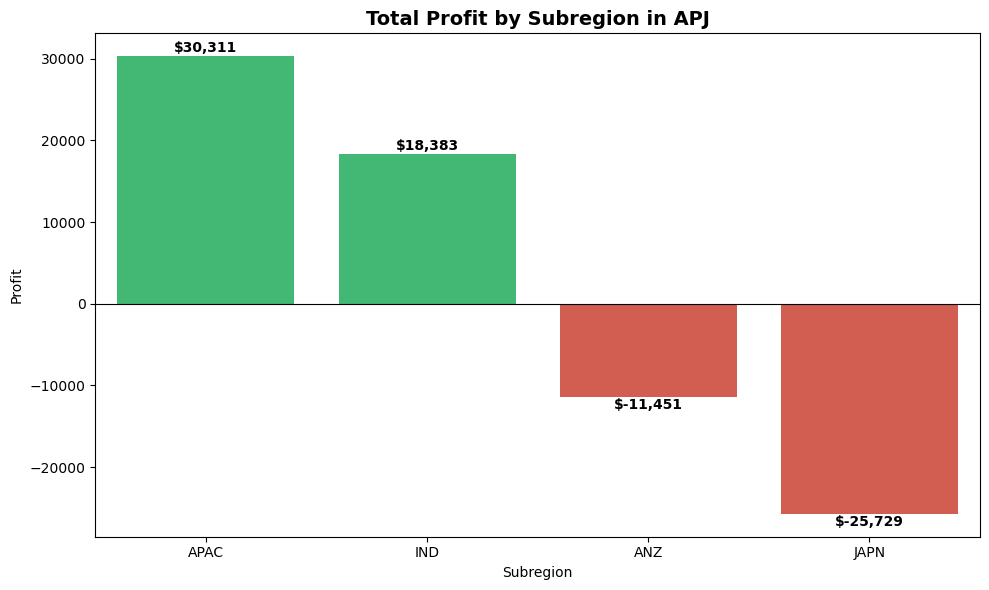

In [70]:
# Visualization: Bar plot of profit by subregion

plot_data = subregion_detail.reset_index()

plt.figure(figsize=(10, 6))

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in plot_data['Profit']]

sns.barplot(data=plot_data, x='Subregion', y='Profit', palette=colors)

plt.title('Total Profit by Subregion in APJ', fontsize=14, fontweight='bold')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Subregion')


for i, v in enumerate(plot_data['Profit']):
    plt.text(i, v + (500 if v > 0 else -1500), f'${v:,.0f}', 
             ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

#### **Explanations for Profit and Sales Performance by Subregion (APJ)**

*Description:*

This chart breaks down the performance within the APJ region into four subregions. We can see a huge contrast here: APAC and India (IND) are doing great, bringing in healthy profits. However, Japan (JAPN) and Australia/New Zealand (ANZ) are struggling with significant losses, despite Japan having the highest sales volume ($170k).

*Critical Insight:*

The situation in Japan is the most concerning. Even though it generates the most revenue, it ends up with a massive loss of -$25,729. This proves that high sales do not always mean high profit. In this case, the more we sell in Japan, the more money we seem to lose, likely due to the aggressive 80% discounting strategy we found earlier.

#### **C. Country**

The JAPN subregion is identified as having the lowest profit within the APJ region, with values even reaching negative levels. Therefore, the analysis is further extended to the country level to validate which specific country is the main source of the losses.

In [71]:
japn_detail = df[df['Subregion'] == 'JAPN']

In [72]:
country_detail = japn_detail.groupby('Country')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)
country_detail

,Sales,Profit
Country,,
Japan,170188.0458,-25729.3563


In [77]:
country_all = df.groupby('Country')['Profit'].sum().reset_index()

In [85]:
geo_json_data = "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json"

lowest_profit = country_all['Profit'].min()

raw_scale = [
    lowest_profit, 
    -20000, 
    -5000, 
    0, 
    20000, 
    country_all['Profit'].max()
]
myscale = sorted(list(set(raw_scale)))

world_map = folium.Map(location=[20, 0], zoom_start=2)

folium.Choropleth(
    geo_data=geo_json_data,          
    data=country_all,
    columns=['Country', 'Profit'],
    key_on='feature.properties.name',
    threshold_scale=myscale,
    fill_color='RdYlGn',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Total Profit by Country',
    nan_fill_color='white'
).add_to(world_map)

world_map

#### **Explanations for the Country Performance: Japan**

*Description:*

In this section, the data focuses entirely on Japan. The numbers show a very high sales figure of $170,188, which is the highest in the APJ region. However, despite these strong sales, the country ends up with a total profit of -$25,729.

*Critical Insight:*

Japan is a perfect example of why high sales numbers can be deceiving. Even though it is the top revenue generator for the region, it is also the biggest source of financial loss. This confirms that the issue isn't a lack of customers or demand, but rather a problem with the profitability of each sale, likely caused by the extreme discounts being offered in this market.

### **ANALYZING THE CAUSE**

Japan is identified as the country with the lowest profit, recording a total loss of -25,729. This analysis aims to identify the key factors contributing to this loss, including problematic products and the discount strategies applied.

#### **A. Products Analysis**

After identifying Japan as having the lowest profit, the analysis is extended to determine which products contribute the most to the losses. Products are grouped based on total profit to highlight those with the poorest performance.

In [128]:
japn_detail.head()

,Order ID,Order Date,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
14,APJ-2021-118983,2021-11-22,Japan,Saitama,APJ,JAPN,Pfizer,1074,Healthcare,Enterprise,Oneview,D8FGC56NNX,68.810,5,0.8,-123.8580
15,APJ-2021-118983,2021-11-22,Japan,Saitama,APJ,JAPN,Pfizer,1074,Healthcare,Enterprise,Contactmatcher,NRKT5R1A1G,2.544,3,0.8,-3.8160
34,APJ-2023-107727,2023-10-20,Japan,Tokyo,APJ,JAPN,Glencore,1083,Misc,Enterprise,Support,77YXBOVGDH,29.472,3,0.2,9.9468
35,APJ-2022-117590,2022-12-09,Japan,Aichi,APJ,JAPN,Procter & Gamble,1077,Consumer Products,Strategic,Site Analytics,GCT4GPUBVT,1097.544,7,0.2,123.4737
36,APJ-2022-117590,2022-12-09,Japan,Aichi,APJ,JAPN,Procter & Gamble,1077,Consumer Products,Strategic,Saas Connector Pack,TKN9K1JO1D,190.920,5,0.6,-147.9630


In [80]:
product_profit = japn_detail.groupby('Product')['Profit'].sum().sort_values()
product_profit

# The losses in Japan are not evenly distributed, but are driven by a few specific products, particularly 'Contactmatcher'

Product
Contactmatcher               -16921.7504
Oneview                       -6147.2225
Saas Connector Pack           -3312.6786
Big Ol Database               -2666.8434
Marketing Suite               -2391.1377
Financehub                    -2315.2470
Marketing Suite - Gold         -763.7054
Storage                          80.7357
Chatbot Plugin                  316.3538
Saas Connector Pack - Gold      848.1760
Data Smasher                   1105.8501
Support                        1585.6908
Alchemy                        1629.9615
Site Analytics                 3222.4608
Name: Profit, dtype: float64

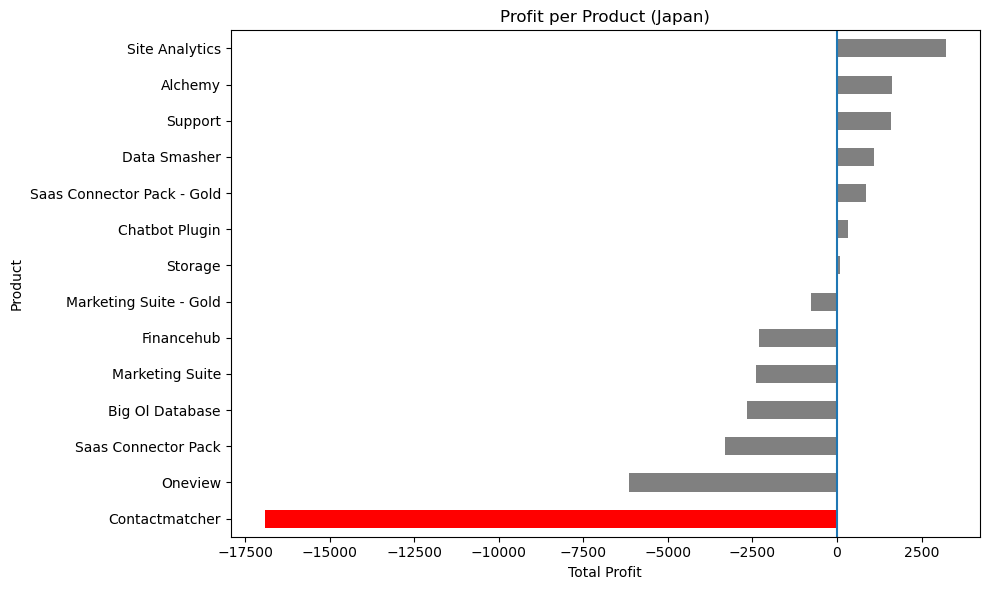

In [82]:
colors = ['red' if product == 'Contactmatcher' else 'gray' 
          for product in product_profit.index]

plt.figure(figsize=(10, 6))
product_profit.plot(kind='barh', color=colors)

# Styling
plt.title('Profit per Product (Japan)')
plt.xlabel('Total Profit')
plt.ylabel('Product')
plt.axvline(0)

plt.tight_layout()
plt.show()

#### **Explanations for the Profit by Product in Japan**

*Description:*

This chart shows which products are making money and which are losing money in the Japanese market. While some products like Site Analytics and Alchemy are profitable, they are not enough to cover the massive losses from other products. Contactmatcher stands out as the biggest problem, with a total loss of nearly -$17,000.

*Notes:*
The loss from Contactmatcher alone accounts for more than half of the total deficit in Japan. Other products like Oneview and SaaS Connector Pack are also significantly in the red. This suggests that the aggressive 80% discount policy might be heavily applied to these specific products, causing them to lose value every time a sale is made.

#### **B. Discount Analysis**

Contactmatcher is identified as the product with the highest loss in Japan. This analysis aims to investigate whether the discount strategy contributes to these losses.

In [44]:
# Validate the relationship between Profit and Discount across all products sold in Japan

japn_detail.groupby(['Product', 'Discount'])['Profit'].agg(['count', 'mean', 'sum'])

count        mean         sum
Product                    Discount                               
Alchemy                    0.20          5  325.992300   1629.9615
Big Ol Database            0.40         13 -205.141800  -2666.8434
Chatbot Plugin             0.20         71    4.455687    316.3538
Contactmatcher             0.30         33  -67.172018  -2216.6766
                           0.80        153  -96.111593 -14705.0738
Data Smasher               0.20         81   13.652470   1105.8501
Financehub                 0.20         30    6.680067    200.4020
                           0.30         61  -41.240148  -2515.6490
Marketing Suite            0.32         27  -88.560656  -2391.1377
Marketing Suite - Gold     0.20         83   -9.201270   -763.7054
Oneview                    0.80         47 -130.791968  -6147.2225
Saas Connector Pack        0.60         81  -40.897267  -3312.6786
Saas Connector Pack - Gold 0.20         30   28.272533    848.1760
Site Analytics             0.20         80   40.280760   3222.4608
Storage                    0.20         24    3.363987     80.7357
Support                    0.20        166    9.552354   1585.6908

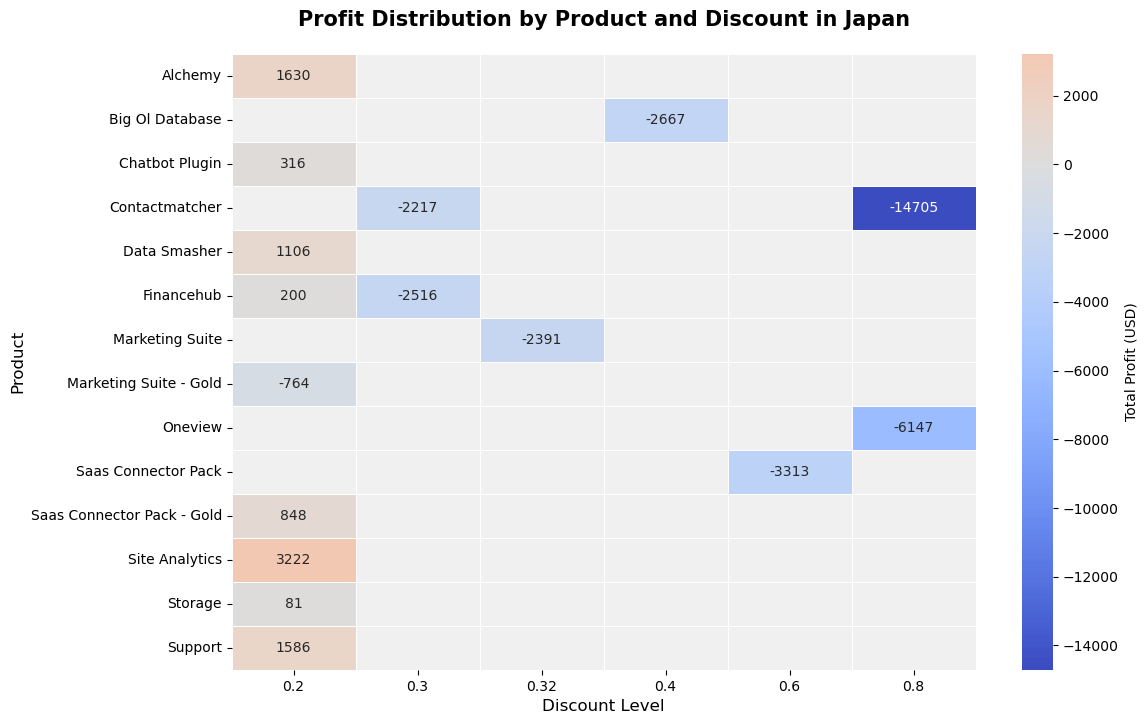

In [46]:
# 1. Pastikan pivot table kamu sudah siap
pivot = japn_detail.pivot_table(
    index='Product', 
    columns='Discount', 
    values='Profit', 
    aggfunc='sum'
)

# 2. Membuat Visualisasi
plt.figure(figsize=(12, 8))

# Kita gunakan 'facecolor' pada plt.subplot untuk mewarnai background kotak yang kosong
ax = plt.subplot(facecolor='#f0f0f0') 

sns.heatmap(
    pivot, 
    annot=True, 
    fmt=".0f", 
    cmap="coolwarm", 
    center=0,        # Memastikan warna putih ada di angka 0
    linewidths=0.5,  # Memberi garis tipis antar kotak agar lebih rapi
    linecolor='white',
    cbar_kws={'label': 'Total Profit (USD)'}
)

plt.title('Profit Distribution by Product and Discount in Japan', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Discount Level', fontsize=12)
plt.ylabel('Product', fontsize=12)

plt.show()

In [47]:
# Further analysis specifically for the Contactmatcher product

japn_detail[japn_detail['Product'] == 'Contactmatcher'].groupby('Discount')['Profit'].agg(['count', 'mean', 'sum'])

,count,mean,sum
Discount,,,
0.3,33,-67.172018,-2216.6766
0.8,153,-96.111593,-14705.0738


#### **Explanations for the Contactmatcher Performance in Japan**

*Description:*

This analysis focuses on Contactmatcher, the product with the heaviest losses. The data shows two different discount levels used for this product: 30% (0.3) and 80% (0.8). The vast majority of sales (153 transactions) were made using the extreme 80% discount, while only 33 transactions used the 30% discount.

*Critical Insight:*

The 80% discount is the primary cause of the loss for this product. It resulted in a massive total loss of -$14,705, with an average loss of -$96 per sale. Even with a smaller 30% discount, the product still loses money, but the 80% discount makes the situation much worse because it is used so frequently.

#### **C. Global vs Japan Contactmatcher - Discount Comparison**

This analysis aims to validate whether the high discount applied to Contactmatcher is a Japan-specific anomaly or a strategy that is also implemented globally.

In [50]:
# Comparison of average discount and profit (Japan vs. Global) for the problematic product
problem_products = ['Contactmatcher']

for prod in problem_products:
    japan = df[(df['Country'] == 'Japan') & (df['Product'] == prod)]
    world = df[(df['Country'] != 'Japan') & (df['Product'] == prod)]
    
    print(f"{prod}")
    print(f"Japan  → Avg Discount: {japan['Discount'].mean():.0%} | Avg Profit/transaksi: {japan['Profit'].mean():.2f}")
    print(f"World  → Avg Discount: {world['Discount'].mean():.0%} | Avg Profit/transaksi: {world['Profit'].mean():.2f}")
    print()

Contactmatcher
Japan  → Avg Discount: 71% | Avg Profit/transaksi: -90.98
World  → Avg Discount: 31% | Avg Profit/transaksi: 17.76



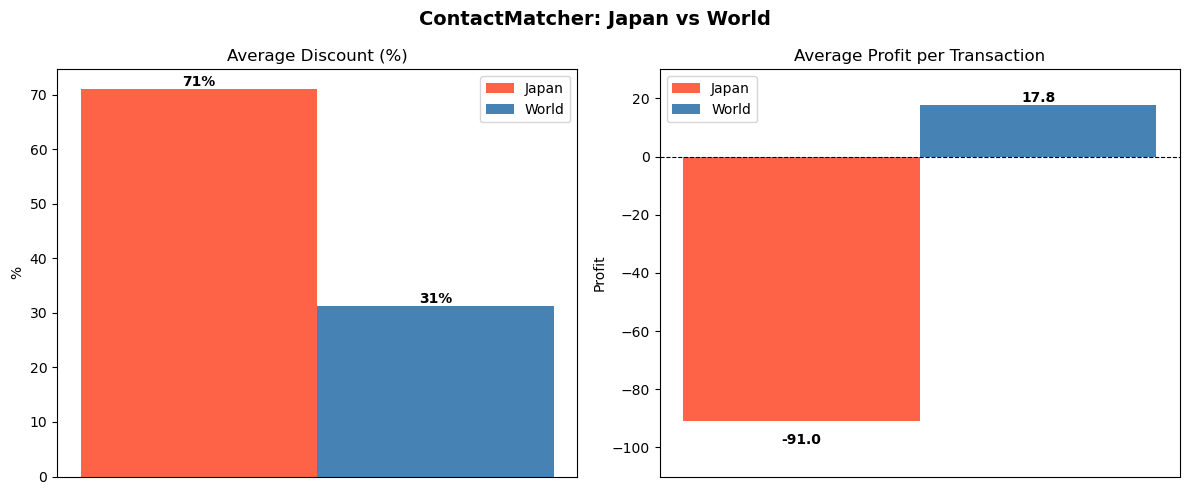

In [51]:
# Visualization 

prod = 'Contactmatcher'
japan = df[(df['Country'] == 'Japan') & (df['Product'] == prod)]
world = df[(df['Country'] != 'Japan') & (df['Product'] == prod)]

japan_vals = [japan['Discount'].mean() * 100, japan['Profit'].mean()]
world_vals = [world['Discount'].mean() * 100, world['Profit'].mean()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ContactMatcher: Japan vs World', fontsize=14, fontweight='bold')

x = np.arange(1)
width = 0.35

# Chart 1: Avg Discount
axes[0].bar(x - width/2, japan_vals[0], width, label='Japan', color='tomato')
axes[0].bar(x + width/2, world_vals[0], width, label='World', color='steelblue')
axes[0].set_title('Average Discount (%)')
axes[0].set_ylabel('%')
axes[0].set_xticks([])
axes[0].legend()
for i, v in enumerate([japan_vals[0], world_vals[0]]):
    axes[0].text(x + (i - 0.5) * width, v + 0.5, f'{v:.0f}%', ha='center', fontweight='bold')

# Chart 2: Avg Profit
axes[1].bar(x - width/2, japan_vals[1], width, label='Japan', color='tomato')
axes[1].bar(x + width/2, world_vals[1], width, label='World', color='steelblue')
axes[1].set_title('Average Profit per Transaction')
axes[1].set_ylabel('Profit')
axes[1].set_xticks([])
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].legend()
for i, v in enumerate([japan_vals[1], world_vals[1]]):
    offset = -8 if v < 0 else 1
    axes[1].text(x + (i - 0.5) * width, v + offset, f'{v:.1f}', ha='center', fontweight='bold')
    axes[1].set_ylim(-110, 30)

plt.tight_layout()
plt.show()

##### **Explanations for the Global vs Local Contactmatcher Discount Comparison**

In Japan, Contactmatcher is sold with an average discount of 71%, meaning the selling price is reduced to only 29% of its original value. As a result, each transaction generates an average loss of -90.98. Outside Japan, the average discount for Contactmatcher is significantly lower, at only 31%. Consequently, each transaction generates an average profit of +17.76.

Two key conclusions can be drawn from this:
1. The product itself is not the issue. Contactmatcher performs profitably in other countries, indicating that the product is neither flawed nor lacking demand.
2. The issue lies in the discount strategy applied in Japan. A 71% discount is excessively high, causing the selling price to fall below cost, which results in losses for every transaction.

#### **D. Discount and Profit Summary**

This section summarizes the relationship between discount levels and profitability across all products in Japan. The goal is to identify a discount threshold that separates profitable transactions from loss-generating ones.

In [52]:
# Summary table

# Group by discount level and observe average profit
japan_summary = japn_detail.groupby('Discount')['Profit'].agg(['mean', 'sum', 'count']).round(2)
japan_summary = japan_summary.sort_index()
print(japan_summary)

            mean       sum  count
Discount                         
0.20       14.43   8225.93    570
0.30      -50.34  -4732.33     94
0.32      -88.56  -2391.14     27
0.40     -205.14  -2666.84     13
0.60      -40.90  -3312.68     81
0.80     -104.26 -20852.30    200


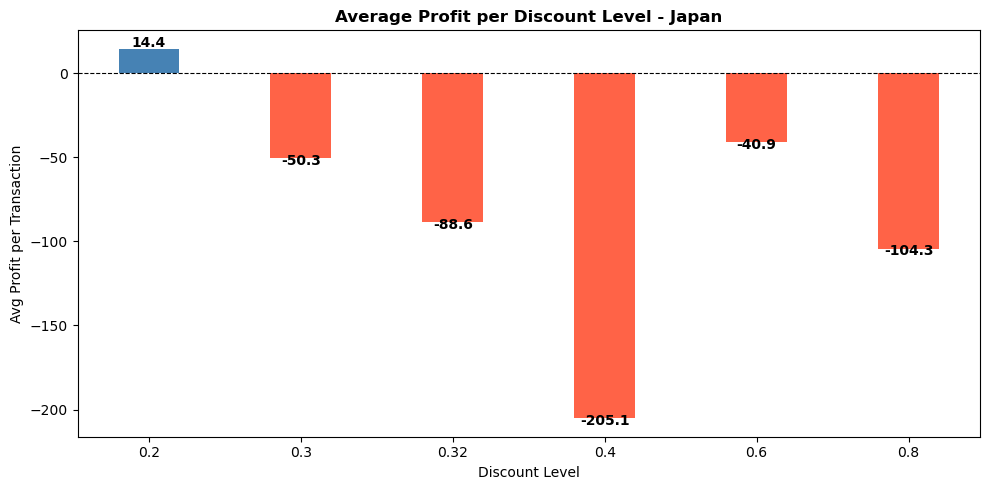

In [53]:
# Visualization

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['tomato' if x < 0 else 'steelblue' for x in japan_summary['mean']]

ax.bar(japan_summary.index.astype(str), japan_summary['mean'], color=colors, width=0.4)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Average Profit per Discount Level - Japan', fontweight='bold')
ax.set_xlabel('Discount Level')
ax.set_ylabel('Avg Profit per Transaction')

for i, (idx, row) in enumerate(japan_summary.iterrows()):
    offset = 1 if row['mean'] >= 0 else -4
    ax.text(i, row['mean'] + offset, f"{row['mean']:.1f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

##### **Explanations for the Discount and Profit Summary**

Based on the analysis, discounts that support profitability are those below 30%. Discounts above 30% consistently lead to losses.

- A 20% discount is the only level that remains profitable (+14.4).
- Discounts of 30% and above all result in losses, without exception.
- The higher the discount, the greater the loss — this pattern is highly consistent.

Therefore, rather than setting a general threshold at 30%, it is more accurate to conclude that only a 20% discount level remains safe and sustainable in the Japanese market.

## **Business Recommendation**

Based on the analysis, the following recommendations are proposed:

**1. Limit the Maximum Discount for Contactmatcher in Japan**  

Contactmatcher has been proven to be profitable in other countries with an average discount of 31%. However, in Japan, the average discount reaches 71%—more than double. It is recommended to set a maximum discount limit of 20% to maintain profitability, as the analysis shows that only discounts of ≤20% still generate profit in Japan.

**2. Investigate the Discount Policy in Japan**  

An internal audit should be conducted to understand why the sales team in Japan is able to offer discounts of up to 80%. This may be driven by specific policies, competitive pressures, or a lack of managerial control.

**3. Use Profitable Products as a Benchmark**  

Products such as Site Analytics, Support, and Data Smasher remain profitable in Japan with discounts of only around 20%. This pattern can be used as a benchmark when defining discount strategies for other products.

## **Conclusion**

This analysis successfully identified the root cause of profit losses in Japan. The issue is not the product itself, but the excessive discount policy applied  to ContactMatcher — averaging 71% in Japan versus only 31% globally. Addressing this discount strategy is the key to turning Japan's operations profitable.